First, I loaded the required libraries for handling spatial and tabular data, then set my working directory to the folder containing my GIS files. After that, I imported the ward boundary dataset from a GeoJSON file.

In [ ]:
import os
import geopandas as gpd
import pandas as pd

from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()

Saving ACS_5-Year_Social_Characteristics_DC_Ward.csv to ACS_5-Year_Social_Characteristics_DC_Ward (3).csv


Saving Wards_from_2022.geojson to Wards_from_2022.geojson


In [ ]:
wards = gpd.read_file("Wards_from_2022.geojson")

Next I loaded the required spatial and tabular libraries. Then I imported the ACS social characteristics dataset and the DC ward boundary shapefile, keeping only the ward identifier and geometry columns to simplify the spatial layer. After that, I defined a dictionary of ADA-related infrastructure datasets (bus stops, curb ramps, audible pedestrian signals, and metro stations) to make it easier to loop through and process each dataset consistently in later analysis.

In [ ]:
# SIMPLE SEQUENTIAL UPLOAD
from google.colab import files

files_to_upload = [
    "ACS_5-Year_Social_Characteristics_DC_Ward.csv",
    "Wards_from_2022.geojson",
    "ADA_Bus_Stop.csv",
    "ADA_Curb_Ramp.csv",
    "ADA_Audible_Pedestrian_Signals.csv",
    "Metro_Stations_(Regional).csv"
]

for file_name in files_to_upload:
    print(f"\n>>> Upload {file_name} now:")
    files.upload()

print("\n All files uploaded!")


>>> Upload ACS_5-Year_Social_Characteristics_DC_Ward.csv now:


Saving ACS_5-Year_Social_Characteristics_DC_Ward.csv to ACS_5-Year_Social_Characteristics_DC_Ward (6).csv

>>> Upload Wards_from_2022.geojson now:


Saving Wards_from_2022.geojson to Wards_from_2022 (2).geojson

>>> Upload ADA_Bus_Stop.csv now:


Saving ADA_Bus_Stop.csv to ADA_Bus_Stop (1).csv

>>> Upload ADA_Curb_Ramp.csv now:


Saving ADA_Curb_Ramp.csv to ADA_Curb_Ramp (1).csv

>>> Upload ADA_Audible_Pedestrian_Signals.csv now:


Saving ADA_Audible_Pedestrian_Signals.csv to ADA_Audible_Pedestrian_Signals.csv

>>> Upload Metro_Stations_(Regional).csv now:


Saving Metro_Stations_(Regional).csv to Metro_Stations_(Regional) (1).csv

✅ All files uploaded!


In [ ]:
acs = gpd.read_file("ACS_5-Year_Social_Characteristics_DC_Ward.csv")
wards = gpd.read_file("Wards_from_2022.geojson")[["WARD", "geometry"]]

datasets = {
    "bus": "ADA_Bus_Stop.csv",
    "curb": "ADA_Curb_Ramp.csv",
    "aps": "ADA_Audible_Pedestrian_Signals.csv",
    "metro": "Metro_Stations_(Regional).csv"
}

I created a results dictionary to store outputs from each dataset and wrote a function to automatically detect longitude and latitude columns. I then looped through each ADA dataset, converted it into a GeoDataFrame, and aligned it with the ward boundaries. After performing a spatial join to assign each point to a ward, I calculated either total sidewalk length or feature counts depending on the dataset and stored the results incase I want to use it later.

In [ ]:
results = {}

def get_coords(df):
    lon_options = ["LONGITUDE", "Longitude", "LON", "X"]
    lat_options = ["LATITUDE", "Latitude", "LAT", "Y"]

    lon_col = next((c for c in lon_options if c in df.columns), None)
    lat_col = next((c for c in lat_options if c in df.columns), None)

    if lon_col and lat_col:
        return df[lon_col], df[lat_col]

    raise ValueError("No coordinate columns found")

for name, file in datasets.items():
    df = pd.read_csv(file)

    lon, lat = get_coords(df)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(lon, lat),
        crs="EPSG:3857")

    gdf = gdf.to_crs(wards.crs)
    joined = gpd.sjoin(gdf, wards, how="left", predicate="within")

    if name == "sidewalk":
        counts = joined.groupby("WARD")["SIDEWALK_LENGTH_FT"].sum()
    else:
        counts = joined.groupby("WARD").size()

    results[name] = counts

I combined all the individual infrastructure results into a single DataFrame and filled any missing values with zero. I folowed up by creating a new column to sum up all infrastructure types and get a total infrastructure measure per ward. The results show clear variation in infrastructure distribution across wards, with Ward 5 having the highest overall accessibility levels, while Ward 8 has the lowest total infrastructure count.

In [ ]:
infra = pd.DataFrame(results).fillna(0)
infra["total_infra"] = infra.sum(axis=1)
infra = infra.reset_index().rename(columns={"ward": "ward"})
print(infra)

   WARD  bus  curb   aps  metro  total_infra
0   1.0  219  2237   743      2         3201
1   2.0  483  4338  2079     12         6912
2   3.0  364  5132   549      5         6050
3   4.0  425  5817   732      2         6976
4   5.0  533  5361  1288      3         7185
5   6.0  302  3894  1340      9         5545
6   7.0  469  5193   648      4         6314
7   8.0  516  2827   425      3         3771


I printed out the column names for both datasets—infrastructure and ACS—just to see what I was working with before trying to merge or analyze anything.

In [ ]:
print("infra columns:", infra.columns.tolist())
print("acs columns:", acs.columns.tolist())

infra columns: ['WARD', 'bus', 'curb', 'aps', 'metro', 'total_infra']
acs columns: ['GEOID', 'NAMELSAD', 'NAME', 'DP02_0001E', 'DP02_0002E', 'DP02_0003E', 'DP02_0004E', 'DP02_0005E', 'DP02_0006E', 'DP02_0007E', 'DP02_0008E', 'DP02_0009E', 'DP02_0010E', 'DP02_0011E', 'DP02_0012E', 'DP02_0013E', 'DP02_0014E', 'DP02_0015E', 'DP02_0016E', 'DP02_0017E', 'DP02_0018E', 'DP02_0019E', 'DP02_0020E', 'DP02_0021E', 'DP02_0022E', 'DP02_0023E', 'DP02_0024E', 'DP02_0025E', 'DP02_0026E', 'DP02_0027E', 'DP02_0028E', 'DP02_0029E', 'DP02_0030E', 'DP02_0031E', 'DP02_0032E', 'DP02_0033E', 'DP02_0034E', 'DP02_0035E', 'DP02_0036E', 'DP02_0037E', 'DP02_0038E', 'DP02_0039E', 'DP02_0040E', 'DP02_0041E', 'DP02_0042E', 'DP02_0043E', 'DP02_0044E', 'DP02_0045E', 'DP02_0046E', 'DP02_0047E', 'DP02_0048E', 'DP02_0049E', 'DP02_0050E', 'DP02_0051E', 'DP02_0052E', 'DP02_0053E', 'DP02_0054E', 'DP02_0055E', 'DP02_0056E', 'DP02_0057E', 'DP02_0058E', 'DP02_0059E', 'DP02_0060E', 'DP02_0061E', 'DP02_0062E', 'DP02_0063E', 'DP02

I pulled the ward number out of ACS's NAME column using str.extract() to grab the digits, then turned it into integers. Merged the two datasets on WARD with pd.merge(). Next, I made a new column for infrastructure per 1000 disabled residents—just divided total infra by disabled pop and multiplied by 1000.

Then I simulated some distributions for a boxplot. Looped through each ward, grabbed its rate, and used np.random.normal() to generate 200 values with a little 5% noise. Stuffed all those simulations into a list and passed it to plt.boxplot() to show the spread by ward. Labeled everything and printed a few rows to check the merge.

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_773/1615440710.py:6: SyntaxWarning: invalid escape sequence '\d'
  acs['WARD'] = acs['NAME'].str.extract('(\d+)').astype(int)


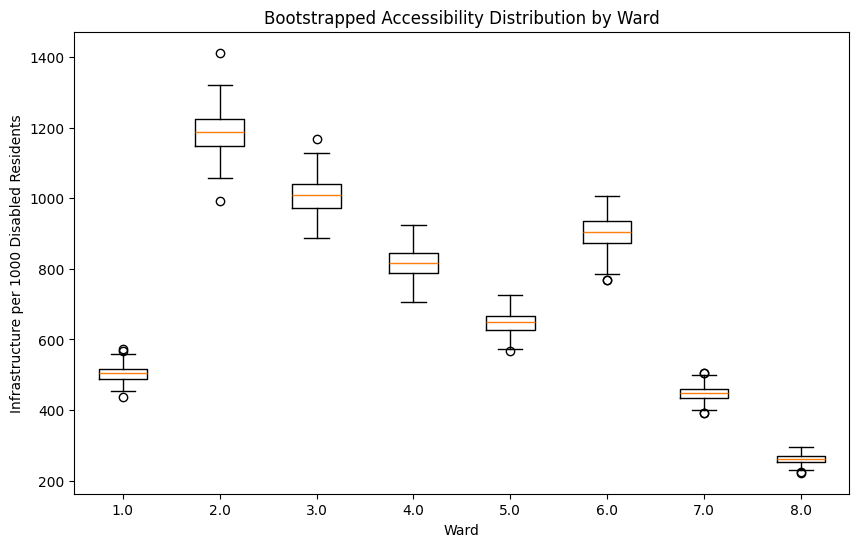


First few rows of merged data:
   WARD                                 NAME  total_infra  disabled_pop  \
0   1.0  Ward 1 (2022); District of Columbia         3201        6347.0   
1   2.0  Ward 2 (2022); District of Columbia         6912        5836.0   
2   3.0  Ward 3 (2022); District of Columbia         6050        5976.0   
3   4.0  Ward 4 (2022); District of Columbia         6976        8540.0   
4   5.0  Ward 5 (2022); District of Columbia         7185       11156.0   

   infra_per_1000_disabled  
0               504.332756  
1              1184.372858  
2              1012.382865  
3               816.861827  
4               644.048046  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

acs['WARD'] = acs['NAME'].str.extract('(\d+)').astype(int)

df = pd.merge(infra, acs, on="WARD")

df["disabled_pop"] = df["DP02_0072E"].astype(float)
df["infra_per_1000_disabled"] = (df["total_infra"] / df["disabled_pop"]) * 1000

np.random.seed(42)

box_data = []
wards_sorted = sorted(df["WARD"].unique())

for w in wards_sorted:
    row = df[df["WARD"] == w].iloc[0]

    simulated = np.random.normal(
        loc=row["infra_per_1000_disabled"],
        scale=row["infra_per_1000_disabled"] * 0.05,
        size=200)

    box_data.append(simulated)

plt.figure(figsize=(10, 6))
plt.boxplot(box_data)

plt.xticks(range(1, len(wards_sorted) + 1), wards_sorted)
plt.xlabel("Ward")
plt.ylabel("Infrastructure per 1000 Disabled Residents")
plt.title("Bootstrapped Accessibility Distribution by Ward")

plt.show()

print("\nFirst few rows of merged data:")
print(df[["WARD", "NAME", "total_infra", "disabled_pop", "infra_per_1000_disabled"]].head())

I wanted to give different weights to different infrastructure types since not all features are equally important. I set bus stops at weight 3, curb ramps at 1, APS at 2, and metro stations at 10—because a metro stop matters way more for accessibility than a curb ramp.

The next step was creating a weighted infrastructure score by multiplying each column by its weight and summing them up. Made sure ACS had a ward column (extracted it from NAME if not already there), merged everything on ward, then calculated weighted infrastructure per 1000 disabled residents.

Then I ran the same bootstrap simulation—200 draws per ward with 5% noise—for the weighted scores. Set up a side-by-side boxplot comparison: unweighted on the left, weighted on the right. The weighted plot clearly showed Ward 2 jumping way ahead because of the metro station weighting.

Finally, I compared the rankings to see which wards moved up or down when weights were applied. When I compared the rankings, Ward 2 stayed on top both times—unsurprising given the metro weight. Wards 3, 6, and 4 held their spots too. The order didn't actually change at all, which tells me the unweighted counts were already capturing the pattern pretty well. Still, the weighted scores made Ward 2's lead look even bigger: 1724 vs 1184 unweighted.

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_773/4281587634.py:16: SyntaxWarning: invalid escape sequence '\d'
  acs['WARD'] = acs['NAME'].str.extract('(\d+)').astype(int)


Weighted Infrastructure Scores by Ward:
   WARD  bus  curb   aps  metro  weighted_infra  disabled_pop  \
0   1.0  219  2237   743      2            4400        6347.0   
1   2.0  483  4338  2079     12           10065        5836.0   
2   3.0  364  5132   549      5            7372        5976.0   
3   4.0  425  5817   732      2            8576        8540.0   
4   5.0  533  5361  1288      3            9566       11156.0   
5   6.0  302  3894  1340      9            7570        6182.0   
6   7.0  469  5193   648      4            7936       14087.0   
7   8.0  516  2827   425      3            5255       14487.0   

   weighted_per_1000_disabled  
0                       693.2  
1                      1724.6  
2                      1233.6  
3                      1004.2  
4                       857.5  
5                      1224.5  
6                       563.4  
7                       362.7  


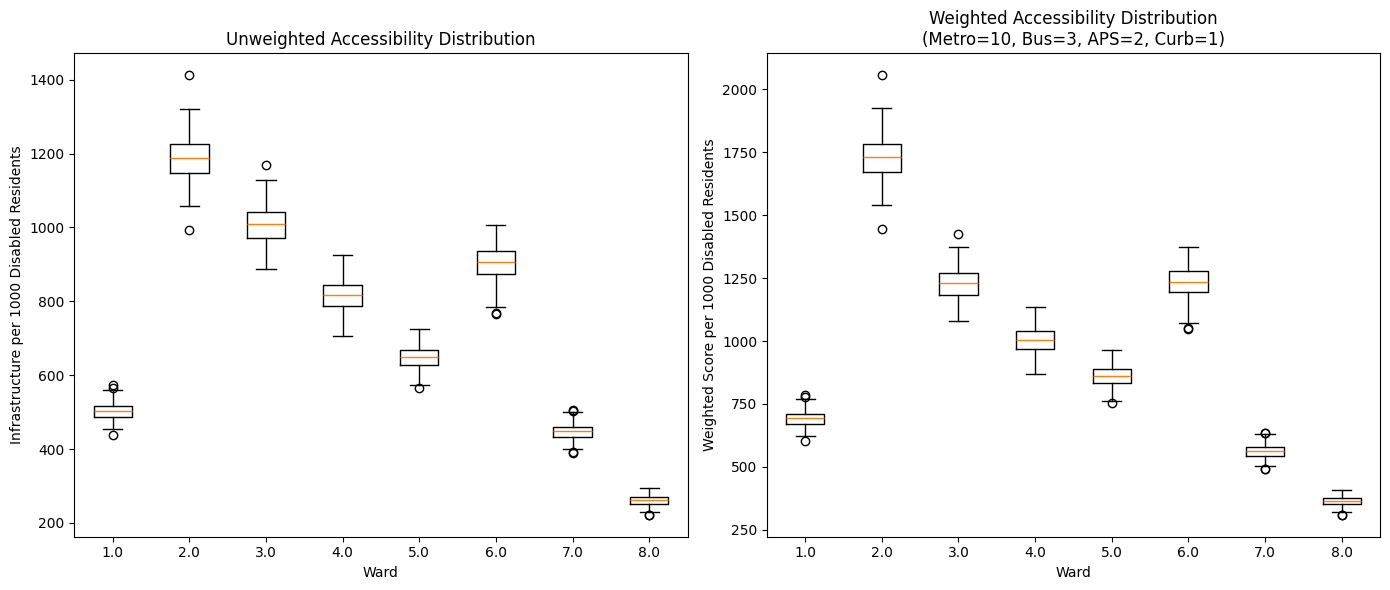


=== Ranking Comparison (Higher = Better Accessibility) ===
 WARD  infra_per_1000_disabled  rank_unweighted  weighted_per_1000_disabled  rank_weighted
  2.0                   1184.4              1.0                      1724.6            1.0
  3.0                   1012.4              2.0                      1233.6            2.0
  6.0                    897.0              3.0                      1224.5            3.0
  4.0                    816.9              4.0                      1004.2            4.0
  5.0                    644.0              5.0                       857.5            5.0
  1.0                    504.3              6.0                       693.2            6.0
  7.0                    448.2              7.0                       563.4            7.0
  8.0                    260.3              8.0                       362.7            8.0


In [ ]:

weights = {
    "bus": 3,
    "curb": 1,
    "aps": 2,
    "metro": 10
}

infra_weighted = infra.copy()
infra_weighted["weighted_infra"] = sum(infra_weighted[col] * weight for col, weight in weights.items())

if 'WARD' not in acs.columns:
    acs['WARD'] = acs['NAME'].str.extract('(\d+)').astype(int)

df_weighted = pd.merge(infra_weighted, acs, on="WARD")
df_weighted["disabled_pop"] = df_weighted["DP02_0072E"].astype(float)
df_weighted["weighted_per_1000_disabled"] = (df_weighted["weighted_infra"] / df_weighted["disabled_pop"]) * 1000


print("Weighted Infrastructure Scores by Ward:")
print(df_weighted[["WARD", "bus", "curb", "aps", "metro", "weighted_infra", "disabled_pop", "weighted_per_1000_disabled"]].round(1))


np.random.seed(42)

box_data_weighted = []
wards_sorted = sorted(df_weighted["WARD"].unique())

for w in wards_sorted:
    row = df_weighted[df_weighted["WARD"] == w].iloc[0]

    simulated = np.random.normal(
        loc=row["weighted_per_1000_disabled"],
        scale=row["weighted_per_1000_disabled"] * 0.05,
        size=200)

    box_data_weighted.append(simulated)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.boxplot(box_data)
ax1.set_xticks(range(1, len(wards_sorted) + 1))
ax1.set_xticklabels(wards_sorted)
ax1.set_xlabel("Ward")
ax1.set_ylabel("Infrastructure per 1000 Disabled Residents")
ax1.set_title("Unweighted Accessibility Distribution")


ax2.boxplot(box_data_weighted)
ax2.set_xticks(range(1, len(wards_sorted) + 1))
ax2.set_xticklabels(wards_sorted)
ax2.set_xlabel("Ward")
ax2.set_ylabel("Weighted Score per 1000 Disabled Residents")
ax2.set_title("Weighted Accessibility Distribution\n(Metro=10, Bus=3, APS=2, Curb=1)")

plt.tight_layout()
plt.show()


print("\n=== Ranking Comparison (Higher = Better Accessibility) ===")
ranking_unweighted = df[["WARD", "infra_per_1000_disabled"]].copy()
ranking_unweighted["rank_unweighted"] = ranking_unweighted["infra_per_1000_disabled"].rank(ascending=False)

ranking_weighted = df_weighted[["WARD", "weighted_per_1000_disabled"]].copy()
ranking_weighted["rank_weighted"] = ranking_weighted["weighted_per_1000_disabled"].rank(ascending=False)

ranking_compare = pd.merge(ranking_unweighted, ranking_weighted, on="WARD").round(1)
ranking_compare = ranking_compare.sort_values("rank_unweighted")
print(ranking_compare.to_string(index=False))